# Week 2 — Pull MdnC homologs & make your first alignment

**Goal for this notebook:** end up with (1) a FASTA file of ~40–80 real MdnC relatives that you pulled yourself, and (2) a multiple sequence alignment of them. That's the Week 2 milestone and the foundation for everything after.

**How to use this:**
1. Put this file in your `notebooks/` folder.
2. Make sure your `microviridin` conda environment is active and Jupyter is running.
3. Edit the email line in the first code cell.
4. Run the cells **top to bottom**, one at a time, reading the comments as you go.

**One heads-up:** the BLAST step (Step 1) talks to NCBI over the web and takes roughly **5–15 minutes**. That's normal. We save the result to disk so you only ever wait once.


### Setup — imports and your email
NCBI asks everyone who uses their servers from a script to provide an email, so they can reach you if something goes wrong. It's required, not optional.

In [2]:
# --- Setup: import the tools we need ---
# Biopython does the heavy lifting: talking to NCBI, running BLAST, reading sequences.
from pathlib import Path              # a clean way to work with files and folders
import time                           # to pause politely between NCBI requests
import shutil                         # to check whether a program (clustalo) is installed

from Bio.Blast import NCBIWWW, NCBIXML   # NCBIWWW runs BLAST over the web; NCBIXML reads its results
from Bio import Entrez, SeqIO            # Entrez fetches sequences by ID; SeqIO reads/writes FASTA files

# NCBI requires an email so they can contact you if a script misbehaves.
Entrez.email = "phamminh1@ufl.edu"     # <-- CHANGE THIS to your real email before running

assert "YOUR_EMAIL" not in Entrez.email, "Edit the line above and put your real email in first."
print("Setup complete. Email set to:", Entrez.email)

Setup complete. Email set to: phamminh1@ufl.edu


### Load your MdnC query sequence
We don't need to download anything new — your query comes straight from the **5IG9** structure file you already have. 5IG9 contains several chains (the big MdnC enzyme plus the short MdnA peptide); MdnC is by far the longest, so we just grab the longest sequence.

In [4]:
# --- Find your data folder and load the MdnC query sequence ---
# This notebook lives in notebooks/, so the data folder is one level up: ../data
DATA = Path("../data") if Path("../data").exists() else Path("data")
DATA.mkdir(exist_ok=True)             # create it if it doesn't exist yet
print("Using data folder:", DATA.resolve())

# Find the 5IG9 FASTA you downloaded (the name can vary, e.g. '5IG9.fasta' or 'rcsb_pdb_5IG9.fasta').
matches  = [p for p in DATA.glob("*.fasta") if "5ig9" in p.name.lower()]
matches += [p for p in DATA.glob("*.txt")   if "5ig9" in p.name.lower()]
if not matches:
    raise FileNotFoundError(
        f"Couldn't find a 5IG9 FASTA in {DATA.resolve()}. "
        "Move the 5IG9 FASTA file into your data/ folder and re-run this cell."
    )
fasta_5ig9 = matches[0]
print("Found:", fasta_5ig9.name)

# MdnC is the longest chain in 5IG9 -> pick the longest sequence as our query.
records      = list(SeqIO.parse(fasta_5ig9, "fasta"))
query_record = max(records, key=lambda r: len(r.seq))
query_seq    = str(query_record.seq)
print(f"\nUsing the longest chain as the MdnC query: {len(query_seq)} residues")
print("First 60 residues:", query_seq[:60])
print(query_seq[190:195])   # positions 191-195 (Python counts from 0)

Using data folder: /Users/phamchutuanminh/Documents/microviridin-project/data
Found: rcsb_pdb_5IG9.fasta

Using the longest chain as the MdnC query: 333 residues
First 60 residues: MTVLIVTFSRDNESIPLVIKAIEAMGKKAFRFDTDRFPTEVKVDLYSGGQKGGIITDGDQ
EDLDN


### Step 1 — BLAST against NCBI (the slow step ☕)
BLAST compares your MdnC sequence against millions of others and returns the most similar ones. This is how we "pull homologs." We save the raw result to disk immediately, so if you re-run the notebook later you skip the wait entirely.

In [5]:
# --- Step 1: BLAST the MdnC sequence against NCBI to find relatives ---
blast_xml = DATA / "mdnC_blast.xml"

if blast_xml.exists():
    print("Found a saved BLAST result already - skipping the slow step.")
    print("(Delete", blast_xml.name, "if you ever want to re-run BLAST from scratch.)")
else:
    print("Running BLAST... this can take 5-15 minutes. Go get a coffee - it's not frozen.")
    t0 = time.time()
    result_handle = NCBIWWW.qblast(
        program="blastp",     # protein-vs-protein search
        database="nr",        # 'nr' = NCBI's big non-redundant protein database
        sequence=query_seq,
        hitlist_size=250,     # ask for up to 250 hits; we filter these down next
    )
    blast_xml.write_text(result_handle.read())   # save raw result so we never re-run the slow part
    result_handle.close()
    print(f"Done in {(time.time()-t0)/60:.1f} minutes. Saved to {blast_xml.name}")


Running BLAST... this can take 5-15 minutes. Go get a coffee - it's not frozen.
Done in 1.1 minutes. Saved to mdnC_blast.xml


In [6]:
xml = DATA / "mdnC_blast.xml"
print("File size (KB):", round(xml.stat().st_size / 1024, 1))
print("Number of hits:", open(xml).read().count("<Hit>"))


File size (KB): 491.6
Number of hits: 250


### Step 2 — Keep only good, in-family hits
We filter on three things so the alignment stays clean. All three are **tunable** — raise `MIN_IDENTITY` for a tighter, closer family; lower it for a broader set.

In [7]:
# --- Step 2: read the BLAST results and keep only good, in-family hits ---
#   E-value      : how likely the match is just chance (smaller = better; we want tiny)
#   % identity   : how similar the sequences are (higher = closer relative)
#   coverage     : how much of your query the match spans (we want most of it)
MAX_EVALUE   = 1e-10
MIN_IDENTITY = 25.0    # percent  (try 30-35 for a tighter set)
MIN_COVERAGE = 70.0    # percent
QLEN = len(query_seq)

accessions = []
with open(blast_xml) as fh:
    blast_record = NCBIXML.read(fh)          # one query -> one record, so we use .read()
    for alignment in blast_record.alignments:
        best = alignment.hsps[0]             # best local match for this hit
        pid  = 100.0 * best.identities  / best.align_length
        cov  = 100.0 * best.align_length / QLEN
        if best.expect <= MAX_EVALUE and pid >= MIN_IDENTITY and cov >= MIN_COVERAGE:
            accessions.append(alignment.accession)

accessions = list(dict.fromkeys(accessions))  # drop duplicate accessions, keep order

if not accessions:
    print("No hits passed the filters. Either BLAST returned nothing, or the thresholds are too")
    print("strict - try lowering MIN_IDENTITY to 20 and re-running this cell. If it's still empty,")
    print("your saved BLAST file may be empty (delete it and re-run Step 1).")
else:
    print(f"{len(accessions)} hits passed the filters.")
    print("First few accessions:", accessions[:5])

250 hits passed the filters.
First few accessions: ['5IG9_A', 'WP_002792265', 'WP_150975421', 'WP_272015294', 'WP_288032792']


### Step 3 — Download the full sequences and save one FASTA
BLAST only returns the matching *region* of each hit. For a proper alignment we want each **full** protein, so we fetch them by accession, drop exact duplicates, cap the total, and add your MdnC query in as the first sequence.

In [8]:
# --- Step 3: download FULL sequences for those hits and save them as one FASTA ---
MAX_SEQS  = 80                       # keep the set manageable for a first alignment
out_fasta = DATA / "mdnC_homologs.fasta"

collected = []
seen_seqs = {query_seq}              # don't include the query itself, and skip exact repeats

for i in range(0, len(accessions), 50):        # 50 accessions per request
    batch  = accessions[i:i+50]
    handle = Entrez.efetch(db="protein", id=",".join(batch), rettype="fasta", retmode="text")
    for rec in SeqIO.parse(handle, "fasta"):
        s = str(rec.seq)
        if s and s not in seen_seqs:
            seen_seqs.add(s)
            collected.append(rec)
    handle.close()
    time.sleep(0.5)                  # brief pause to be polite to NCBI
    if len(collected) >= MAX_SEQS:
        break

collected = collected[:MAX_SEQS]

# Label the query clearly and put it first, so it's part of the alignment.
query_record.id          = "MdnC_5IG9_query"
query_record.description = "MdnC query from 5IG9"
final_set = [query_record] + collected

SeqIO.write(final_set, out_fasta, "fasta")
print(f"Saved {len(final_set)} sequences (query + {len(collected)} homologs) to {out_fasta.name}")

Saved 81 sequences (query + 80 homologs) to mdnC_homologs.fasta


### Step 4 — Quick sanity check
Most sequences should be roughly MdnC-sized (~300–330 residues). A pile of very short or very long ones means some junk slipped through — tighten the filters in Step 2 if so.

Matplotlib is building the font cache; this may take a moment.


Number of sequences: 81
Length  ->  min 324 | median 324 | max 343


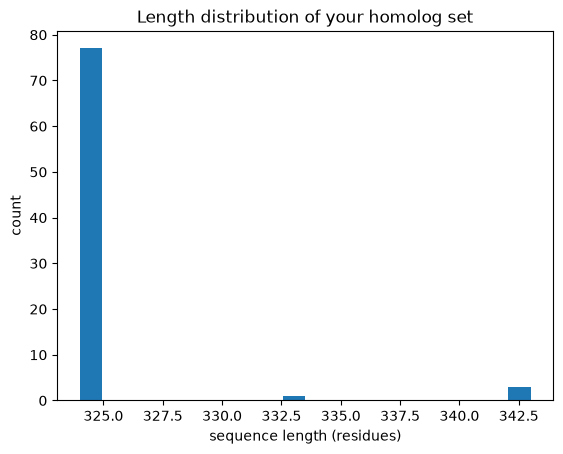

In [9]:
# --- Step 4: sanity check what we pulled ---
import statistics
import matplotlib.pyplot as plt

lengths = [len(r.seq) for r in final_set]
print("Number of sequences:", len(lengths))
print(f"Length  ->  min {min(lengths)} | median {int(statistics.median(lengths))} | max {max(lengths)}")

plt.hist(lengths, bins=20)
plt.xlabel("sequence length (residues)")
plt.ylabel("count")
plt.title("Length distribution of your homolog set")
plt.show()

### Step 5 — Align them (your Week 2 milestone 🎯)
Clustal Omega lines the sequences up so equivalent positions sit in the same column. It's a separate program — install it once in Terminal with `brew install clustal-omega`, then run this cell.

In [10]:
# --- Step 5: align all the sequences (auto-detects MAFFT or Clustal Omega) ---
import subprocess
aln_out = DATA / "mdnC_homologs_aligned.fasta"

if shutil.which("mafft"):
    print("Aligning with MAFFT... (usually under a minute)")
    with open(aln_out, "w") as out:            # MAFFT prints the alignment to standard output
        subprocess.run(["mafft", "--auto", str(out_fasta)], stdout=out, check=True)
    print("Alignment saved to", aln_out.name)
elif shutil.which("clustalo"):
    print("Aligning with Clustal Omega...")
    subprocess.run(
        ["clustalo", "-i", str(out_fasta), "-o", str(aln_out),
         "--outfmt=fasta", "--force", "--threads=4"],
        check=True,
    )
    print("Alignment saved to", aln_out.name)
else:
    print("No aligner found yet. In Terminal run:  brew install mafft   then re-run this cell.")

Aligning with MAFFT... (usually under a minute)


outputhat23=16
treein = 0
compacttree = 0
stacksize: 8176 kb
rescale = 1
All-to-all alignment.
tbfast-pair (aa) Version 7.526
alg=L, model=BLOSUM62, 2.00, -0.10, +0.10, noshift, amax=0.0
0 thread(s)

outputhat23=16
Loading 'hat3.seed' ... 
done.
Writing hat3 for iterative refinement
rescale = 1
Gap Penalty = -1.53, +0.00, +0.00
tbutree = 1, compacttree = 0
Constructing a UPGMA tree ... 
   70 / 81
done.

Progressive alignment ... 
STEP    72 /80 
Reallocating..done. *alloclen = 1695
STEP    80 /80 
done.
tbfast (aa) Version 7.526
alg=A, model=BLOSUM62, 1.53, -0.00, -0.00, noshift, amax=0.0
1 thread(s)

minimumweight = 0.000010
autosubalignment = 0.000000
nthread = 0
randomseed = 0
blosum 62 / kimura 200
poffset = 0
niter = 16
sueff_global = 0.100000
nadd = 16
Loading 'hat3' ... done.
rescale = 1

   70 / 81
Segment   1/  1    1- 353
STEP 002-079-1  identical.   
Converged.

done
dvtditr (aa) Version 7.526
alg=A, model=BLOSUM62, 1.53, -0.00, -0.00, noshift, amax=0.0
0 thread(s)


Strate

Alignment saved to mdnC_homologs_aligned.fasta


## ✅ Week 2 done — what you just built

- `mdnC_blast.xml` — your raw BLAST results (the slow step, saved so you never repeat it)
- `mdnC_homologs.fasta` — the MdnC relatives you pulled, plus your query
- `mdnC_homologs_aligned.fasta` — your first multiple sequence alignment

**Now commit to GitHub** (GitHub Desktop → write a short message like *"Week 2: MdnC homologs + first alignment"* → Commit → Push). Your `data/` folder finally has real contents.

**Sanity check to feel good about:** the residues you found in ChimeraX (E191, D192, N195, and the ATP-pocket set) should fall in the *conserved* columns of your alignment. If they do, your pipeline is on the rails.

**Next week (Week 3):** turn this alignment into a conservation score for every position, and start mapping it onto the 5IG9 structure.

*If BLAST misbehaves* (hangs past ~20 min, or Step 2 finds nothing), stop and tell me — I'll hand you a curated-accession version that skips BLAST entirely.
